# 02 · Prediction — who is likely to leave

> Synthetic data; method demonstration.

Thin wrapper over `src/predict` and `src/interpret`. Regenerate the artifacts with `make predict`; here we read the committed metric tables and figures.

In [1]:
import os, sys
from pathlib import Path

# Make the repo root the working dir and importable, whether this notebook is
# launched from notebooks/ or from the repo root.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image
pd.set_option("display.width", 120)
print("repo root:", ROOT)

repo root: /Users/jimmy/Documents/hr-attrition-analytics


## Cross-validated + held-out metrics

The logistic baseline leads and is calibrated, so its scores can legitimately be read as *risk*.

In [2]:
print('5-fold CV (train):')
display(pd.read_csv('figures/metrics_cv.csv'))
print('Held-out test:')
display(pd.read_csv('figures/metrics_test.csv'))

5-fold CV (train):


,model,cv_roc_auc,cv_roc_auc_std,cv_pr_auc,cv_pr_auc_std
0,logit,0.846911,0.046434,0.659411,0.106127
1,gbm,0.798532,0.033518,0.548012,0.049745


Held-out test:


,model,test_roc_auc,test_pr_auc,test_brier
0,logit,0.813724,0.587819,0.098117
1,gbm,0.764412,0.475527,0.118626


## Calibration

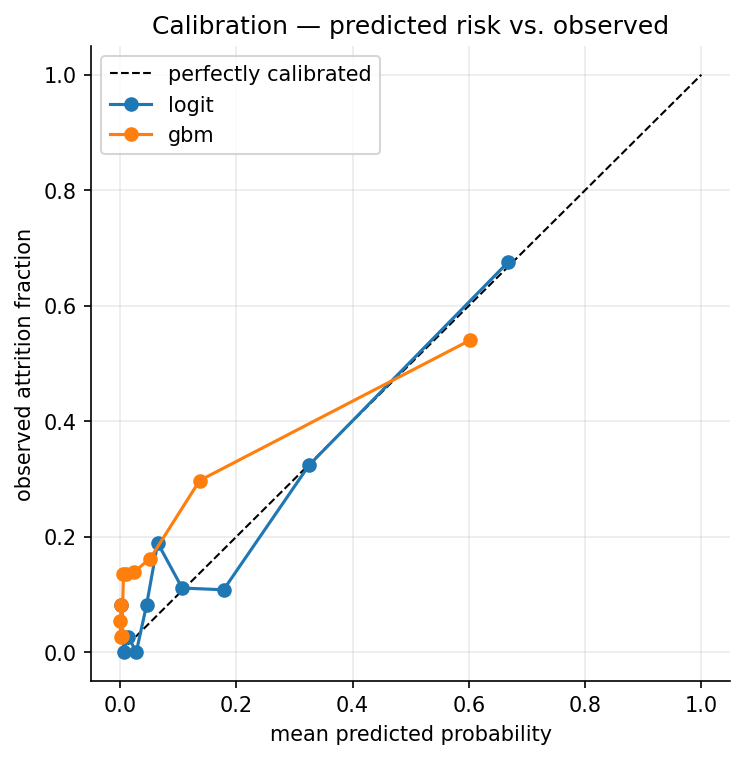

In [3]:
Image('figures/calibration.png')

## What drives the *risk* score (SHAP)

These attribute risk; whether they are movable *levers* is a causal question — Phase 3.

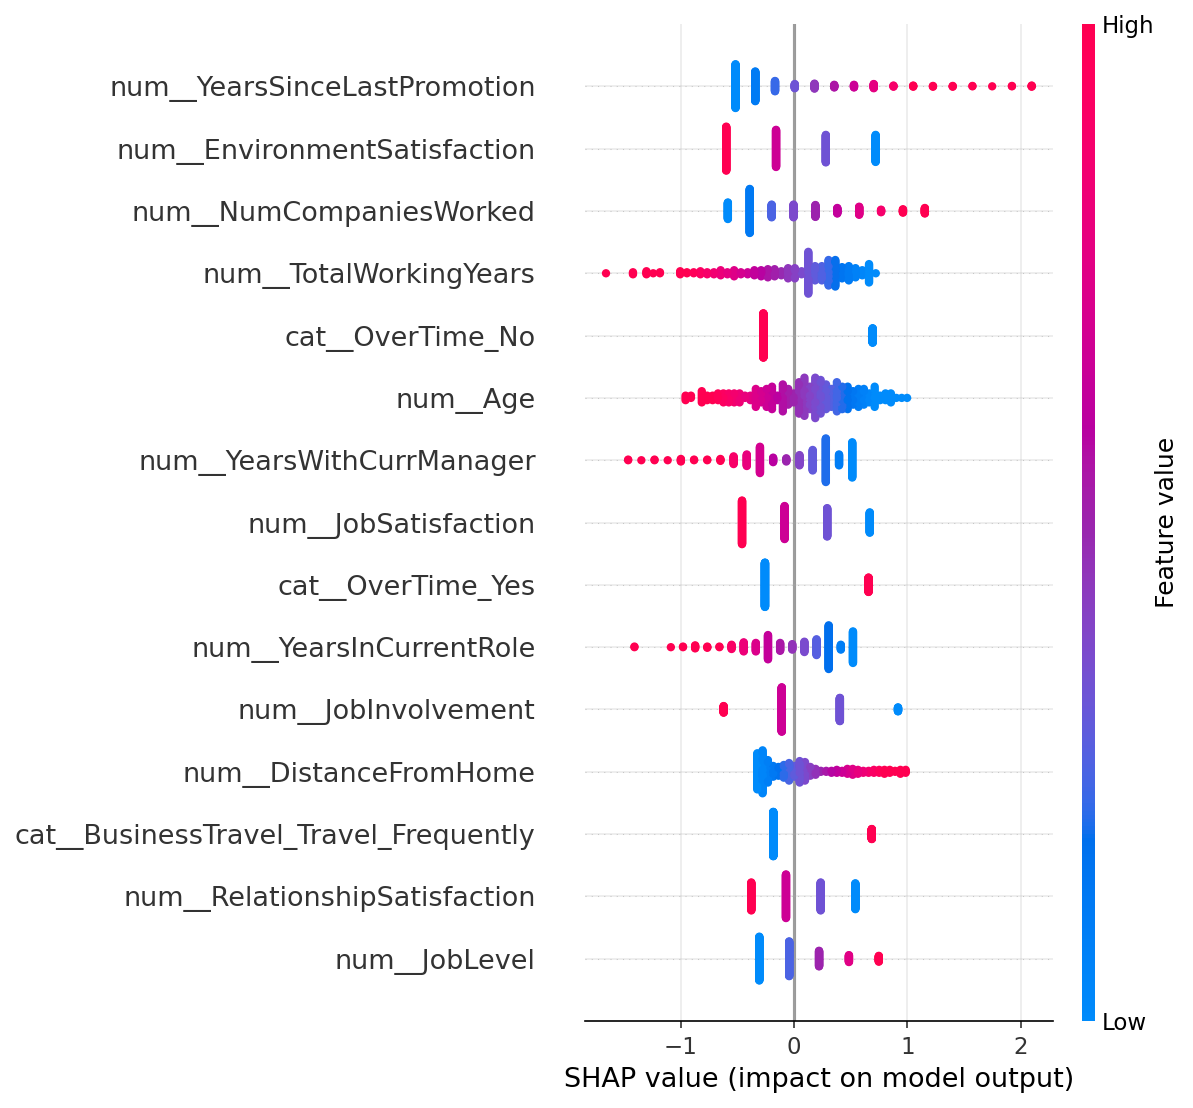

In [4]:
Image('figures/shap_summary.png')

**Takeaway.** A usable risk *ranking*, not an action plan: the score says *who*, not *what to do*. Next: `03_causal.ipynb`.